# Financial Asset Recommendation System

## Part 4 — Baselines, two-tower model and evaluation

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from src.config import PROCESSED_DATA_DIR, RAW_DATA_DIR
from src.preprocessing import clean_data, temporal_user_split
from src.baselines import recommend_popular,recommend_sector_popular,recommend_content
from src.evaluation import evaluate_recommender

# Use processed files when available; otherwise create the split in memory.
assets=pd.read_csv(RAW_DATA_DIR/'assets.csv'); users=pd.read_csv(RAW_DATA_DIR/'users.csv'); interactions=pd.read_csv(RAW_DATA_DIR/'interactions.csv')
assets,users,interactions=clean_data(assets,users,interactions)
train,validation,test=temporal_user_split(interactions)

## 1. Baseline models

The baselines establish whether personalization adds value beyond globally popular assets and simple feature similarity.

In [3]:
baseline_functions={
'Popularity':lambda uid,k:recommend_popular(train,uid,k),
'Sector popularity':lambda uid,k:recommend_sector_popular(train,users,assets,uid,k),
'Content similarity':lambda uid,k:recommend_content(train,assets,uid,k),
}
baseline_results={name:evaluate_recommender(test,fn,k=10) for name,fn in baseline_functions.items()}
results=pd.DataFrame(baseline_results).T
results

,precision@10,recall@10,hit_rate@10,mrr@10,unique_recommended_assets
Popularity,0.022000,0.220000,0.220000,0.064072,20.0
Sector popularity,0.037333,0.373333,0.373333,0.148891,60.0
Content similarity,0.021500,0.215000,0.215000,0.061388,60.0


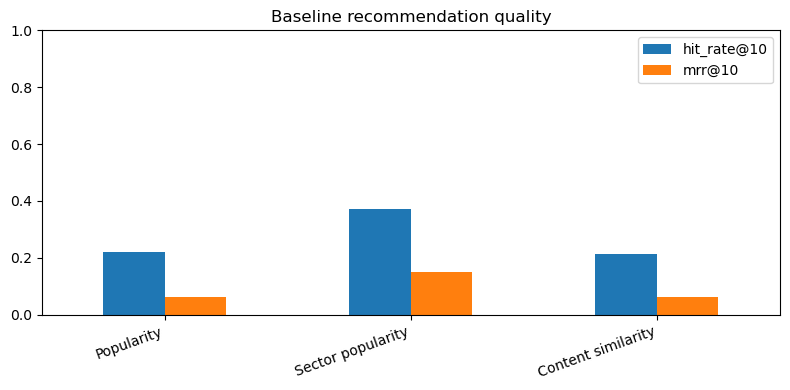

In [4]:
results[['hit_rate@10','mrr@10']].plot.bar(figsize=(8,4),title='Baseline recommendation quality')
plt.xticks(rotation=20,ha='right'); plt.ylim(0,1); plt.tight_layout(); plt.show()

## 2. Two-tower neural recommender

The user tower encodes user ID, risk profile, preferred sector, age and experience. The asset tower encodes ticker, sector and standardized numerical features. Their normalized vectors are compared with a dot product. Negative examples are sampled from assets the user has not interacted with.

In [5]:
import tensorflow as tf
import numpy as np

# This cell requires TensorFlow. It is isolated so the baseline experiment remains runnable without it.
from src.two_tower import build_two_tower_model,make_training_pairs,make_recommend_fn
model,user_tower,asset_tower=build_two_tower_model(users,assets,embedding_dim=32)
x_train,y_train,means,stds=make_training_pairs(train,users,assets,negatives_per_positive=2)


x_train_tf = {}

for key, value in x_train.items():
    arr = np.asarray(value)

    if arr.dtype.kind in {"U", "S", "O"}:
        x_train_tf[key] = tf.convert_to_tensor(
            arr.astype(str),
            dtype=tf.string
        )
    else:
        x_train_tf[key] = tf.convert_to_tensor(
            arr,
            dtype=tf.float32
        )

y_train_tf = tf.convert_to_tensor(
    y_train,
    dtype=tf.float32
)

history = model.fit(
    x_train_tf,
    y_train_tf,
    validation_split=0.15,
    epochs=8,
    batch_size=256,
    verbose=1
)

I0000 00:00:1786443396.995189  130624 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786443397.153041  130624 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786443401.021188  130624 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
E0000 00:00:1786443401.712984  130624 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuIn

Epoch 1/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - auc: 0.5232 - loss: 0.6399 - val_auc: 0.5618 - val_loss: 0.6324
Epoch 2/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - auc: 0.5937 - loss: 0.6278 - val_auc: 0.5859 - val_loss: 0.6285
Epoch 3/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - auc: 0.6351 - loss: 0.6201 - val_auc: 0.5877 - val_loss: 0.6278
Epoch 4/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - auc: 0.6665 - loss: 0.6138 - val_auc: 0.5897 - val_loss: 0.6274
Epoch 5/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - auc: 0.6927 - loss: 0.6094 - val_auc: 0.5907 - val_loss: 0.6274
Epoch 6/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - auc: 0.7091 - loss: 0.6059 - val_auc: 0.5928 - val_loss: 0.6270
Epoch 7/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - auc: 0.7254 - loss: 0.6032 - val_auc: 0.5866 - val_loss: 0.6284
Epoch 8/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - auc: 0.7346 - loss: 0.6013 - val_auc: 0.5820 - val_loss: 0.6298


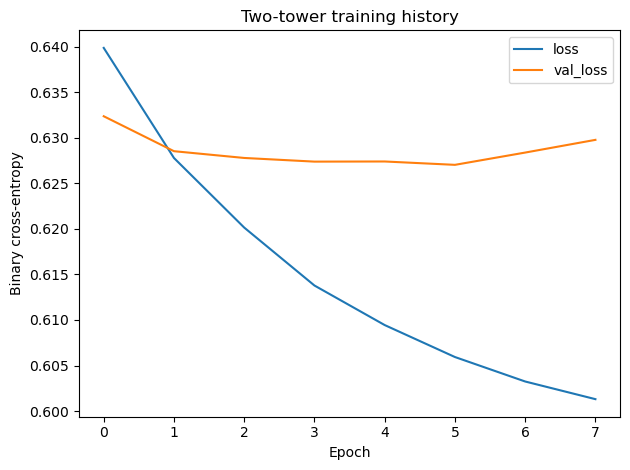

In [6]:
pd.DataFrame(history.history)[['loss','val_loss']].plot(title='Two-tower training history')
plt.xlabel('Epoch'); plt.ylabel('Binary cross-entropy'); plt.tight_layout(); plt.show()

In [7]:
neural_recommend=make_recommend_fn(model,users,assets,train,means,stds)
neural_result=evaluate_recommender(test,neural_recommend,k=10)
results.loc['Two-tower neural']=neural_result
results.sort_values('hit_rate@10',ascending=False)

,precision@10,recall@10,hit_rate@10,mrr@10,unique_recommended_assets
Sector popularity,0.037333,0.373333,0.373333,0.148891,60.0
Two-tower neural,0.027167,0.271667,0.271667,0.088323,56.0
Popularity,0.022000,0.220000,0.220000,0.064072,20.0
Content similarity,0.021500,0.215000,0.215000,0.061388,60.0


## 3. Recommendation example

In [8]:
example_user=users.iloc[0].user_id
profile=users[users.user_id==example_user]
recommendations=neural_recommend(example_user,10) if 'neural_recommend' in globals() else baseline_functions['Sector popularity'](example_user,10)
display(profile)
display(assets[assets.ticker.isin(recommendations)].set_index('ticker').loc[recommendations])

,user_id,age,experience_years,risk_profile,preferred_sector,investment_horizon
0,U00001,36,5,balanced,Consumer,long


,company_name,sector,annual_return,volatility,beta,pe_ratio,dividend_yield,market_cap_billion
ticker,,,,,,,,
FAS009,Synthetic Capital 009,Financials,0.1220,0.1658,0.823,34.33,0.0354,169.91
FAS057,Synthetic Capital 057,Industrials,0.0725,0.1978,0.839,9.90,0.0346,74.61
FAS001,Synthetic Capital 001,Technology,0.2314,0.4327,1.435,14.52,0.0156,255.85
FAS035,Synthetic Capital 035,Real Estate,0.1965,0.3040,1.253,19.54,0.0407,38.97
FAS018,Synthetic Capital 018,Financials,0.1107,0.2601,1.154,20.57,0.0433,88.78
FAS039,Synthetic Capital 039,Healthcare,0.1126,0.3172,1.011,26.11,0.0463,56.79
FAS012,Synthetic Capital 012,Real Estate,0.2191,0.2889,1.048,9.16,0.0254,63.86
FAS059,Synthetic Capital 059,Consumer,0.2031,0.2833,1.013,11.85,0.0243,61.83
FAS058,Synthetic Capital 058,Financials,0.1159,0.2411,0.874,19.49,0.0316,82.23


## 4. Interpretation checklist

- Compare the neural model against every baseline, not only the weakest one.
- Discuss both ranking quality and catalog coverage.
- Do not interpret synthetic recommendation quality as investment performance.
- Record TensorFlow version, random seed, epochs and hardware.
- Re-run several seeds before making a strong claim.

## 5. Conclusion

The starter project provides a complete and testable research pipeline: a defined real-life problem, documented data generation, EDA, chronological evaluation, multiple baselines, a hybrid deep-learning model and clear limitations. The next iteration should replace or supplement synthetic interactions with a versioned public dataset and add an ablation study.